In [1]:
# ====================================================================
# CLASSIFICATION-REGRESSION INFERENCE ON TEST SET
# ====================================================================
# This notebook combines classification and regression models to
# make predictions on the test dataset

import numpy as np
import pandas as pd
import os
import pickle
import os

# List available input data files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/curves-regression-a/__results__.html
/kaggle/input/curves-regression-a/__notebook__.ipynb
/kaggle/input/curves-regression-a/__output__.json
/kaggle/input/curves-regression-a/joint_regression_model.h5
/kaggle/input/curves-regression-a/custom.css
/kaggle/input/curves-regression-a/__results___files/__results___8_0.png
/kaggle/input/curves-regression-a/__results___files/__results___10_0.png
/kaggle/input/curves-regression-a/__results___files/__results___7_0.png
/kaggle/input/datasets/khliland/joint-regression-model-7-h5/joint_regression_model (2).h5
/kaggle/input/curves-classification-a-output/cnn_classification_model.keras
/kaggle/input/curves-data-generation-a/__results__.html
/kaggle/input/curves-data-generation-a/data_classification.pkl
/kaggle/input/curves-data-generation-a/__notebook__.ipynb
/kaggle/input/curves-data-generation-a/__output__.json
/kaggle/input/curves-data-generation-a/custom.css


In [ ]:
# ====================================================================
# LOAD TRAINING DATA AND PARAMETERS
# ====================================================================

with open("/kaggle/input/curves-data-generation-a/data_classification.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
y_train = data["y_train"]
y_left_train = data["y_left_train"]
y_right_train = data["y_right_train"]
X_val = data["X_val"]
y_val = data["y_val"]
y_left_val = data["y_left_val"]
y_right_val = data["y_right_val"]
X_test = data["X_test"]
y_test = data["y_test"]
y_left_test = data["y_left_test"]
y_right_test = data["y_right_test"]
p = data["p"]
q = data["q"]
r = data["r"]
params = data["params"]
BATCH_SIZE = data["BATCH_SIZE"]
STEPS_PER_EPOCH = data["STEPS_PER_EPOCH"]
VALIDATION_STEPS = data["VALIDATION_STEPS"]
TEST_STEPS = data["TEST_STEPS"]
SEGMENTS = data["SEGMENTS"]
EPOCHS = data["EPOCHS"]

In [ ]:
# ====================================================================
# PREPROCESS TG SPECTRA
# ====================================================================
# Use the same derivative/noise contract as the training notebooks.

DERIVATIVE_MODE = "all"  # Must match the trained model: "first", "first_second", or "all"
NOISE_LEVEL = 0.00  # 0.00, 0.01, 0.02, or 0.05; applied to test only
NOISE_SCALING = "per_curve_range"  # "per_curve_range", "global_range", or "absolute"
NOISE_SEED = 42

if DERIVATIVE_MODE not in {"first", "first_second", "all"}:
    raise ValueError("DERIVATIVE_MODE must be 'first', 'first_second', or 'all'")
if NOISE_LEVEL not in {0.00, 0.01, 0.02, 0.05}:
    raise ValueError("NOISE_LEVEL must be 0.00, 0.01, 0.02, or 0.05")
if NOISE_SCALING not in {"per_curve_range", "global_range", "absolute"}:
    raise ValueError("Unsupported NOISE_SCALING")

def add_noise(curves, noise_level=0.0, scaling="per_curve_range", seed=None):
    """Add zero-mean Gaussian noise to TG spectra."""
    curves = np.asarray(curves, dtype=np.float32)
    if noise_level == 0.0:
        return curves.copy()
    rng = np.random.default_rng(seed)
    if scaling == "per_curve_range":
        scale = np.ptp(curves, axis=1, keepdims=True)
    elif scaling == "global_range":
        scale = np.ptp(curves)
    elif scaling == "absolute":
        scale = 1.0
    else:
        raise ValueError("Unsupported noise scaling")
    return curves + rng.normal(0.0, noise_level * scale, size=curves.shape).astype(np.float32)

def build_features(curves, temperature, temp_step, derivative_mode="all"):
    """Convert TG spectra into the selected derivative feature channels."""
    curves = np.asarray(curves, dtype=np.float32)
    first = np.diff(curves, axis=1, prepend=curves[:, :1]) / temp_step
    if derivative_mode == "first":
        return first[..., None]
    if derivative_mode == "first_second":
        second = np.diff(first, axis=1, prepend=first[:, :1]) / temp_step
        return np.stack([first, second], axis=-1)
    if derivative_mode == "all":
        second = np.diff(first, axis=1, prepend=first[:, :1]) / temp_step
        scaled_first = first * np.asarray(temperature, dtype=np.float32)[None, :] ** 2
        return np.stack([first, second, scaled_first], axis=-1)
    raise ValueError("Unsupported derivative mode")

temperature = data["temperature"]
temp_step = data["temp_step"]
X_train = build_features(X_train, temperature, temp_step, DERIVATIVE_MODE)
X_val = build_features(X_val, temperature, temp_step, DERIVATIVE_MODE)
X_test = build_features(
    add_noise(X_test, NOISE_LEVEL, NOISE_SCALING, NOISE_SEED),
    temperature,
    temp_step,
    DERIVATIVE_MODE,
)
print(f"Features: {DERIVATIVE_MODE}, test noise: {NOISE_LEVEL:.0%} ({NOISE_SCALING})")

In [ ]:
# ====================================================================
# LOAD TRAINED MODELS
# ====================================================================
# Load classification and regression models with custom loss functions

import tensorflow as tf
from tensorflow.keras.models import load_model

# Placeholder value for n-parameter (used in custom loss)
N_PLACEHOLDER_VALUE = -1.0

def masked_mse_loss_ignore_placeholder(y_true, y_pred):
    """
    Custom loss function: MSE that ignores targets set to -1.0 placeholder.
    
    Required for loading regression models that use this custom loss on n-outputs.
    """
    from tensorflow.keras import backend as K
    
    mask = K.cast(K.not_equal(y_true, N_PLACEHOLDER_VALUE), K.floatx())
    squared_error = K.square(y_pred - y_true)
    masked_error = squared_error * mask
    num_valid = K.sum(mask) + K.epsilon()
    loss_value = K.sum(masked_error) / num_valid
    
    return loss_value

# Define file paths
REGRESSION_MODEL_PATH = '/kaggle/input/datasets/khliland/joint-regression-model-7-h5/joint_regression_model (2).h5'
CLASSIFICATION_MODEL_PATH = '/kaggle/input/curves-classification-a-output/cnn_classification_model.keras'

# Load models with custom loss
loaded_regression_model = load_model(
    REGRESSION_MODEL_PATH,
    custom_objects={'masked_mse_loss_ignore_placeholder': masked_mse_loss_ignore_placeholder}
)
print(f"✓ Regression model loaded from: {REGRESSION_MODEL_PATH}")

loaded_classification_model = load_model(CLASSIFICATION_MODEL_PATH)
print(f"✓ Classification model loaded from: {CLASSIFICATION_MODEL_PATH}")

2026-05-02 09:28:49.560291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777714129.820634      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777714129.906905      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-05-02 09:29:11.417927: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✓ Regression model loaded from: /kaggle/input/datasets/khliland/joint-regression-model-7-h5/joint_regression_model (2).h5
✓ Classification model loaded from: /kaggle/input/curves-classification-a-output/cnn_classification_model.keras


In [4]:
# ====================================================================
# INFERENCE PIPELINE
# ====================================================================
# Step 1: Classification - identify model types
# Step 2: Regression - predict parameters for identified models

# Configuration
r = 7  # Number of models
N_USING_INDICES = {3, 4}  # Fn=3, JMA=4 (models that use n parameter)
N_PLACEHOLDER_VALUE = -1.0
MODEL_NAMES = ['D2', 'D3', 'D4', 'Fn', 'JMA', 'R2', 'R3']

# ====================================================================
# STEP 1: CLASSIFICATION - Identify model types
# ====================================================================
print("Step 1: Running Classification on Test Data...")

raw_predictions = loaded_classification_model.predict(X_test)
left_pred_softmax = raw_predictions[0]
right_pred_softmax = raw_predictions[1]

# Get predicted class indices
left_pred_int = np.argmax(left_pred_softmax, axis=1)
right_pred_int = np.argmax(right_pred_softmax, axis=1)

# Convert to one-hot for regression model input
from tensorflow.keras.utils import to_categorical
Y_left_test_ID = to_categorical(left_pred_int, num_classes=r)
Y_right_test_ID = to_categorical(right_pred_int, num_classes=r)

print(f"✓ Classification complete. Identified {len(np.unique(left_pred_int))} left models and {len(np.unique(right_pred_int))} right models.")

# ====================================================================
# STEP 2: REGRESSION - Predict parameters
# ====================================================================
print("Step 2: Running Joint Regression Model Inference...")

test_inputs = {
    'curve_input': X_test,
    'left_id_input': Y_left_test_ID, # Predicted left class
    'right_id_input': Y_right_test_ID # Predicted right class
}

regression_predictions = loaded_regression_model.predict(test_inputs)

# Unpack predictions: [ratio, left_A, left_n, right_A, right_n]
pred_ratio = regression_predictions[0]
pred_AL = regression_predictions[1]
pred_nL = regression_predictions[2]
pred_AR = regression_predictions[3]
pred_nR = regression_predictions[4]

print("✓ Regression prediction complete.")

Step 1: Running Classification on Test Data...


I0000 00:00:1777714159.110157     101 service.cc:148] XLA service 0x79c8bc0092b0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777714159.111032     101 service.cc:156]   StreamExecutor device (0): Host, Default Version


   3/4538 ━━━━━━━━━━━━━━━━━━━━ 2:04 28ms/step  

I0000 00:00:1777714159.601018     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4538/4538 ━━━━━━━━━━━━━━━━━━━━ 108s 24ms/step
✓ Classification complete. Identified 7 left models and 7 right models.
Step 2: Running Joint Regression Model Inference...
4538/4538 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step
✓ Regression prediction complete.


In [5]:
# ====================================================================
# STEP 3: POST-PROCESSING - Apply model-aware n-masking
# ====================================================================
# Critical: Only Fn and JMA models use the n parameter
# Set n predictions to NaN for other models to indicate "not applicable"

print("Step 3: Applying model-aware masking to n-predictions...")

M = X_test.shape[0]
final_predictions = np.hstack([pred_ratio, pred_AL, pred_nL, pred_AR, pred_nR])

# Create masks: True where model USES n parameter
left_uses_n = np.isin(left_pred_int, list(N_USING_INDICES))
right_uses_n = np.isin(right_pred_int, list(N_USING_INDICES))

# Set n to NaN for models that don't use it
final_predictions[~left_uses_n, 2] = np.nan   # Index 2: pred_nL
final_predictions[~right_uses_n, 4] = np.nan  # Index 4: pred_nR

# Create output dataframe
left_pred_names = np.array([MODEL_NAMES[idx] for idx in left_pred_int])
right_pred_names = np.array([MODEL_NAMES[idx] for idx in right_pred_int])

output_df = pd.DataFrame(
    final_predictions,
    columns=['Ratio', 'A_Left', 'n_Left', 'A_Right', 'n_Right']
)
output_df['Left_Model'] = left_pred_names
output_df['Right_Model'] = right_pred_names

print(f"\n✓ Final Predictions Generated (with model-aware n-masking)")
print(f"  Samples with valid Left n:  {left_uses_n.sum():6d} / {M}")
print(f"  Samples with valid Right n: {right_uses_n.sum():6d} / {M}")
print(f"\nPreview of results (first 10 rows):")
print(output_df.head(10))

Step 3: Applying model-aware masking to n-predictions...

✓ Final Predictions Generated (with model-aware n-masking)
  Samples with valid Left n:   79933 / 145200
  Samples with valid Right n:  78353 / 145200

Preview of results (first 10 rows):
      Ratio    A_Left  n_Left   A_Right  n_Right Left_Model Right_Model
0  0.705523  0.734504     NaN  0.944669      NaN         D2          D2
1  0.882041  0.622675     NaN  0.781287      NaN         D2          D2
2  0.383692  0.324286     NaN  0.650401      NaN         D2          D2
3  0.048434  0.065508     NaN  0.976490      NaN         D2          D2
4  0.074189  0.169761     NaN  0.871888      NaN         D2          D2
5  0.092915  0.620027     NaN  0.737958      NaN         D2          D2
6  0.387995  0.436491     NaN  0.893811      NaN         D2          D2
7  0.973840  0.702155     NaN  0.779496      NaN         D2          R2
8  0.882961  0.934161     NaN  0.953759      NaN         D2          D2
9  0.483922  0.387760     NaN  0.7

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [6]:
# ====================================================================
# DENORMALIZATION & MODEL-AWARE COMPARISON
# ====================================================================
"""
Denormalize predictions and ground truth using model-specific A-ranges.
Ground truth was normalized under the TRUE model's range during generation.
This cell prepares data for comprehensive error analysis.

Key insight: Using the ground truth model's denormalization range separates
prediction error from range mismatch error (which is just a labeling issue).
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === EXTRACT PARAMETER RANGES ===
logA_range = params['logA_range']
logA_Fn_range = params.get('logA_Fn_range', logA_range)
n_range = params['n_range']
mix_range = params['mix_range']

# Model indices and n-parameter usage mapping
FN_ONLY_INDEX = 3
N_USING_INDICES = {3, 4}  # Fn and JMA

def get_logA_range_for_model(model_idx):
    """Returns the A-range used to normalize this model's data during generation.
    
    CRITICAL: Only Fn (index 3) uses logA_Fn_range. All others including JMA use logA_range.
    
    Args:
        model_idx: Integer 0-6 corresponding to model class
    
    Returns:
        (min, max) tuple for the logA range
    """
    return logA_Fn_range if model_idx == FN_ONLY_INDEX else logA_range

def denormalize_parameter(normalized_value, param_range):
    """Converts from [0, 1] normalized to original scale.
    
    Formula: original = normalized * (max - min) + min
    
    Args:
        normalized_value: Float or array in [0, 1] range
        param_range: (min, max) tuple for the original scale
    
    Returns:
        Value(s) in original scale
    """
    return normalized_value * (param_range[1] - param_range[0]) + param_range[0]

# === PREPARE GROUND TRUTH DATA ===
true_ratio_norm = y_test[:, 2]
true_AL_norm = y_test[:, 4]
true_nL_norm = y_test[:, 1]
true_AR_norm = y_test[:, 3]
true_nR_norm = y_test[:, 0]

# Get ground truth model indices
y_left_test_int = y_left_test.astype(int)
y_right_test_int = y_right_test.astype(int)

# === DENORMALIZE USING GROUND TRUTH MODEL'S RANGE ===
# Left component
Y_true_AL_denorm = np.array([
    denormalize_parameter(true_AL_norm[i], get_logA_range_for_model(y_left_test_int[i]))
    for i in range(len(true_AL_norm))
])

Y_true_nL_denorm = np.array([
    denormalize_parameter(true_nL_norm[i], n_range) if y_left_test_int[i] in N_USING_INDICES else np.nan
    for i in range(len(true_nL_norm))
])

# Right component
Y_true_AR_denorm = np.array([
    denormalize_parameter(true_AR_norm[i], get_logA_range_for_model(y_right_test_int[i]))
    for i in range(len(true_AR_norm))
])

Y_true_nR_denorm = np.array([
    denormalize_parameter(true_nR_norm[i], n_range) if y_right_test_int[i] in N_USING_INDICES else np.nan
    for i in range(len(true_nR_norm))
])

# === DENORMALIZE PREDICTIONS ===
pred_ratio_norm = final_predictions[:, 0]
pred_AL_norm = final_predictions[:, 1]
pred_nL_norm = final_predictions[:, 2]
pred_AR_norm = final_predictions[:, 3]
pred_nR_norm = final_predictions[:, 4]

# Left component
pred_AL_denorm = np.array([
    denormalize_parameter(pred_AL_norm[i], get_logA_range_for_model(y_left_test_int[i]))
    for i in range(len(pred_AL_norm))
])

pred_nL_denorm = np.array([
    denormalize_parameter(pred_nL_norm[i], n_range) if not np.isnan(pred_nL_norm[i]) else np.nan
    for i in range(len(pred_nL_norm))
])

# Right component
pred_AR_denorm = np.array([
    denormalize_parameter(pred_AR_norm[i], get_logA_range_for_model(y_right_test_int[i]))
    for i in range(len(pred_AR_norm))
])

pred_nR_denorm = np.array([
    denormalize_parameter(pred_nR_norm[i], n_range) if not np.isnan(pred_nR_norm[i]) else np.nan
    for i in range(len(pred_nR_norm))
])

# Ratio (same for all models)
Y_true_ratio_denorm = denormalize_parameter(true_ratio_norm, mix_range)
pred_ratio_denorm = denormalize_parameter(pred_ratio_norm, mix_range)

# === CREATE COMPARISON DATAFRAME ===
comparison_df = pd.DataFrame({
    'Ratio_True': Y_true_ratio_denorm,
    'A_Left_True': Y_true_AL_denorm,
    'n_Left_True': Y_true_nL_denorm,
    'A_Right_True': Y_true_AR_denorm,
    'n_Right_True': Y_true_nR_denorm,
    'Ratio_Pred': pred_ratio_denorm,
    'A_Left_Pred': pred_AL_denorm,
    'n_Left_Pred': pred_nL_denorm,
    'A_Right_Pred': pred_AR_denorm,
    'n_Right_Pred': pred_nR_denorm,
    'Left_Model': np.array([MODEL_NAMES[idx] for idx in y_left_test_int]),
    'Right_Model': np.array([MODEL_NAMES[idx] for idx in y_right_test_int]),
})

print("Denormalization complete. Comparison dataframe shape:", comparison_df.shape)


Denormalization complete. Comparison dataframe shape: (145200, 12)



GENERATING COMPARISON PLOTS (Denormalized, Model-Aware)


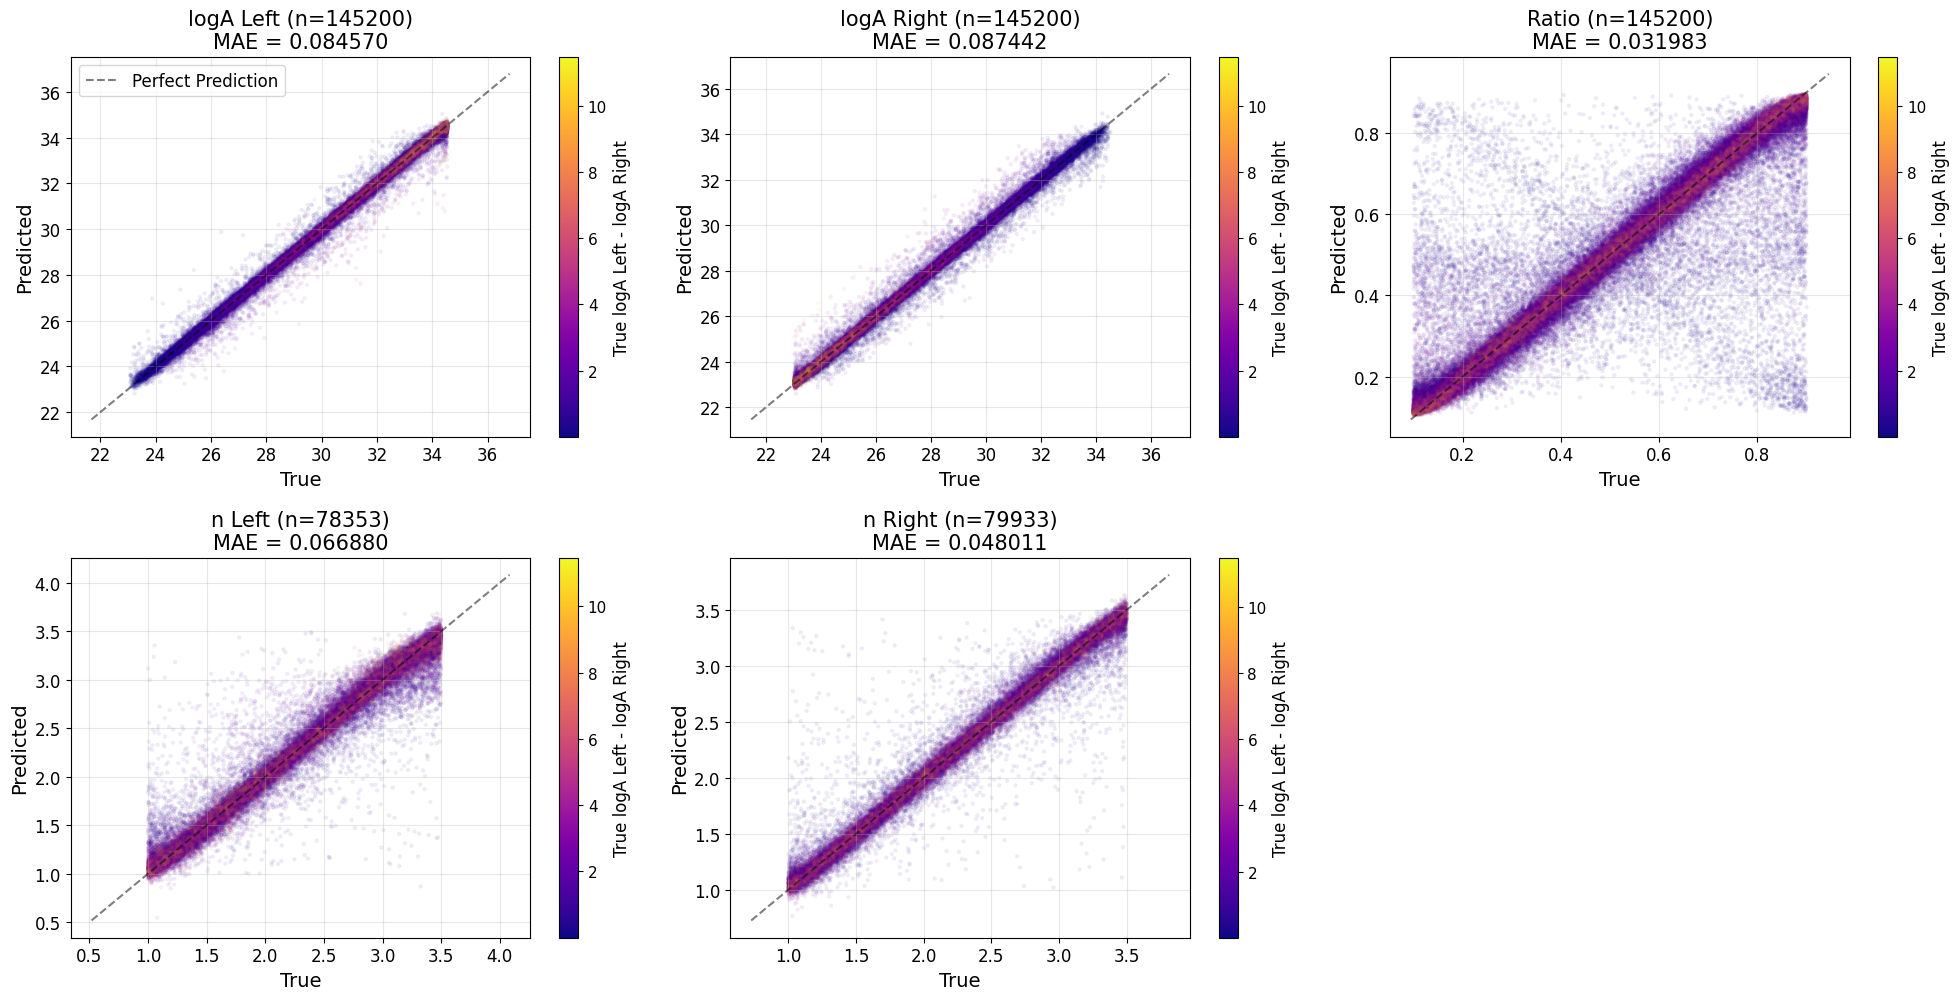

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


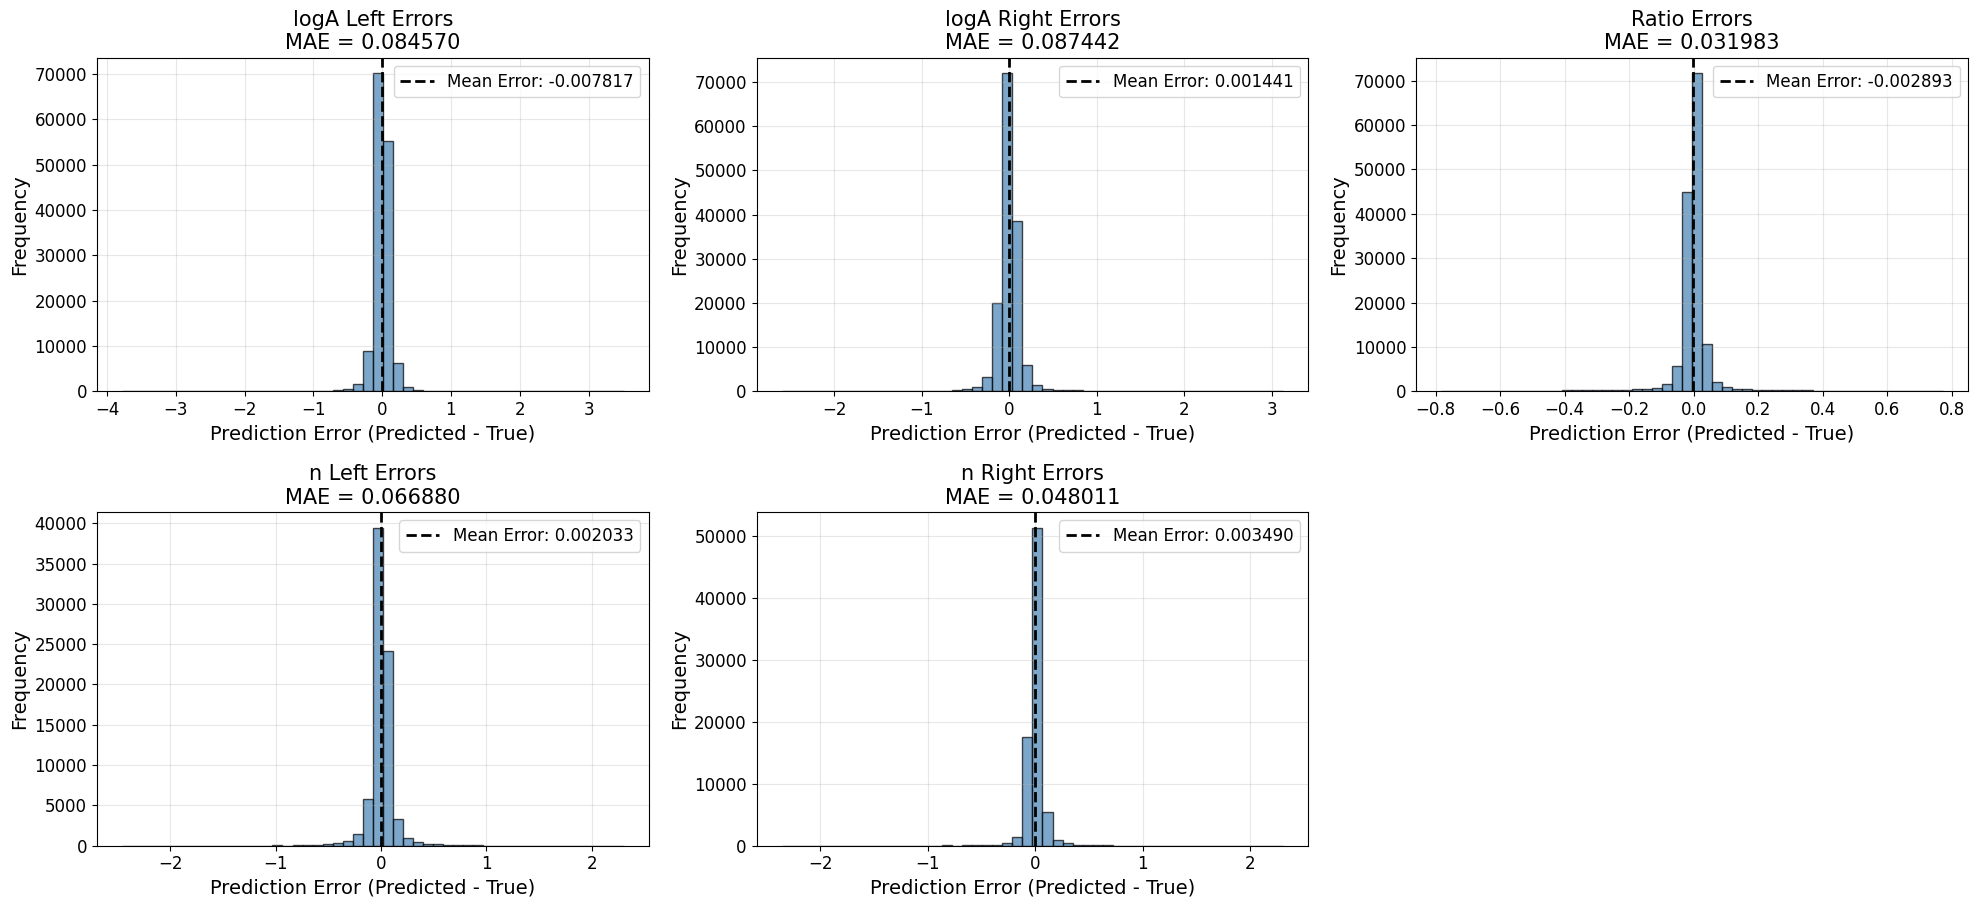


SUMMARY STATISTICS (DENORMALIZED, ORIGINAL SCALE)
Ratio       : MAE = 0.031983 (145200 samples)
logA Right  : MAE = 0.087442 (145200 samples)
n Right     : MAE = 0.048011 (79933 samples)
logA Left   : MAE = 0.084570 (145200 samples)
n Left      : MAE = 0.066880 (78353 samples)


In [ ]:
# =================================================================
# FUNCTION TO GENERATE PLOTS (DENORMALIZED, MODEL-AWARE)
# =================================================================
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
plt.rcParams.update({
    "font.size": 14,         # base size
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 17
})
def plot_regression_metrics(df, pred_int_labels_L, pred_int_labels_R, model_names):
    
    params_list = ['A_Right', 'A_Left', 'Ratio', 'n_Right', 'n_Left']
    param_clist = ['logA Left', 'logA Right', 'Ratio', 'n Left', 'n Right']
    
    # 1. Prediction vs. True Value Scatter Plots
    plt.figure(figsize=(20, 11))
    for i, p in enumerate(params_list):
        plt.subplot(2, 3, i + 1)
        
        # Filter out NaN predictions for 'n' (where n is not applicable)
        plot_df = df.dropna(subset=[f'{p}_Pred']).copy() 
        
        # Compute color dimension AFTER filtering to this subplot's data
        plot_color = plot_df['A_Right_True'] - plot_df['A_Left_True']
        
        # Remove any remaining NaN values in color dimension (from non-n models)
        valid_color_mask = ~np.isnan(plot_color)
        plot_df_valid = plot_df[valid_color_mask]
        plot_color_valid = plot_color[valid_color_mask]
        
        # Get the min and max of this subplot's color values for consistent scaling
        vmin = plot_color_valid.min()
        vmax = plot_color_valid.max()
        
        # Use A_Right - A_Left as color for all plots        
        norm = Normalize(vmin=vmin, vmax=vmax)
        scatter = plt.scatter(plot_df_valid[f'{p}_True'], plot_df_valid[f'{p}_Pred'], 
                            s=5, c=plot_color_valid, cmap='plasma', 
                            alpha=0.05, norm=norm)
        
        # Create a separate colorbar with alpha=1.0 to show true colors
        sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
        sm.set_array([])  # Dummy array to avoid warnings
        cbar = plt.colorbar(sm, ax=plt.gca())
        cbar.set_label('True logA Left - logA Right', fontsize=12)
        cbar.ax.tick_params(labelsize=11)

        # Draw the Y=X line (perfect prediction)
        max_val = max(plot_df[f'{p}_True'].max(), plot_df[f'{p}_Pred'].max()) * 1.05
        min_val = min(plot_df[f'{p}_True'].min(), plot_df[f'{p}_Pred'].min()) * 0.95
        
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
        
        # Calculate and display MAE
        mae = np.mean(np.abs(plot_df[f'{p}_Pred'] - plot_df[f'{p}_True']))
        count = len(plot_df)
        
        plt.title(f'{param_clist[i]} (n={count})\nMAE = {mae:.6f}')
        plt.xlabel('True')
        plt.ylabel('Predicted')
        plt.grid(True, alpha=0.3)
        if i == 0:
            plt.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


    # 2. Error Distribution Histograms
    plt.figure(figsize=(20, 10))
    for i, p in enumerate(params_list):
        plt.subplot(2, 3, i + 1)
        
        plot_df = df.dropna(subset=[f'{p}_Pred']).copy()  # Filter NaN 'n'
        
        error = plot_df[f'{p}_Pred'] - plot_df[f'{p}_True']
        
        plt.hist(error, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        mean_error = error.mean()
        plt.axvline(mean_error, color='k', linestyle='dashed', linewidth=2, 
                   label=f'Mean Error: {mean_error:.6f}')
        
        mae = np.mean(np.abs(error))
        plt.title(f'{param_clist[i]} Errors\nMAE = {mae:.6f}')
        plt.xlabel('Prediction Error (Predicted - True)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)

#    plt.suptitle('Distribution of Prediction Errors (Should be Centered Near Zero)', 
#                fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

# --- EXECUTION ---
print("\n" + "="*80)
print("GENERATING COMPARISON PLOTS (Denormalized, Model-Aware)")
print("="*80)
plot_regression_metrics(comparison_df, left_pred_int, right_pred_int, MODEL_NAMES)

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS (DENORMALIZED, ORIGINAL SCALE)")
print("="*80)
param_name = ['Ratio', 'A_Left', 'n_Left', 'A_Right', 'n_Right']
param_cname = ['Ratio', 'logA Right', 'n Right', 'logA Left', 'n Left']
for p in range(5):
    valid_data = comparison_df.dropna(subset=[f'{param_name[p]}_Pred'])
    if len(valid_data) > 0:
        mae = np.mean(np.abs(valid_data[f'{param_name[p]}_Pred'] - valid_data[f'{param_name[p]}_True']))
        print(f"{param_cname[p]:12s}: MAE = {mae:.6f} ({len(valid_data):5d} samples)")
print("="*80)


GENERATING COMPARISON PLOTS (Denormalized, Model-Aware)


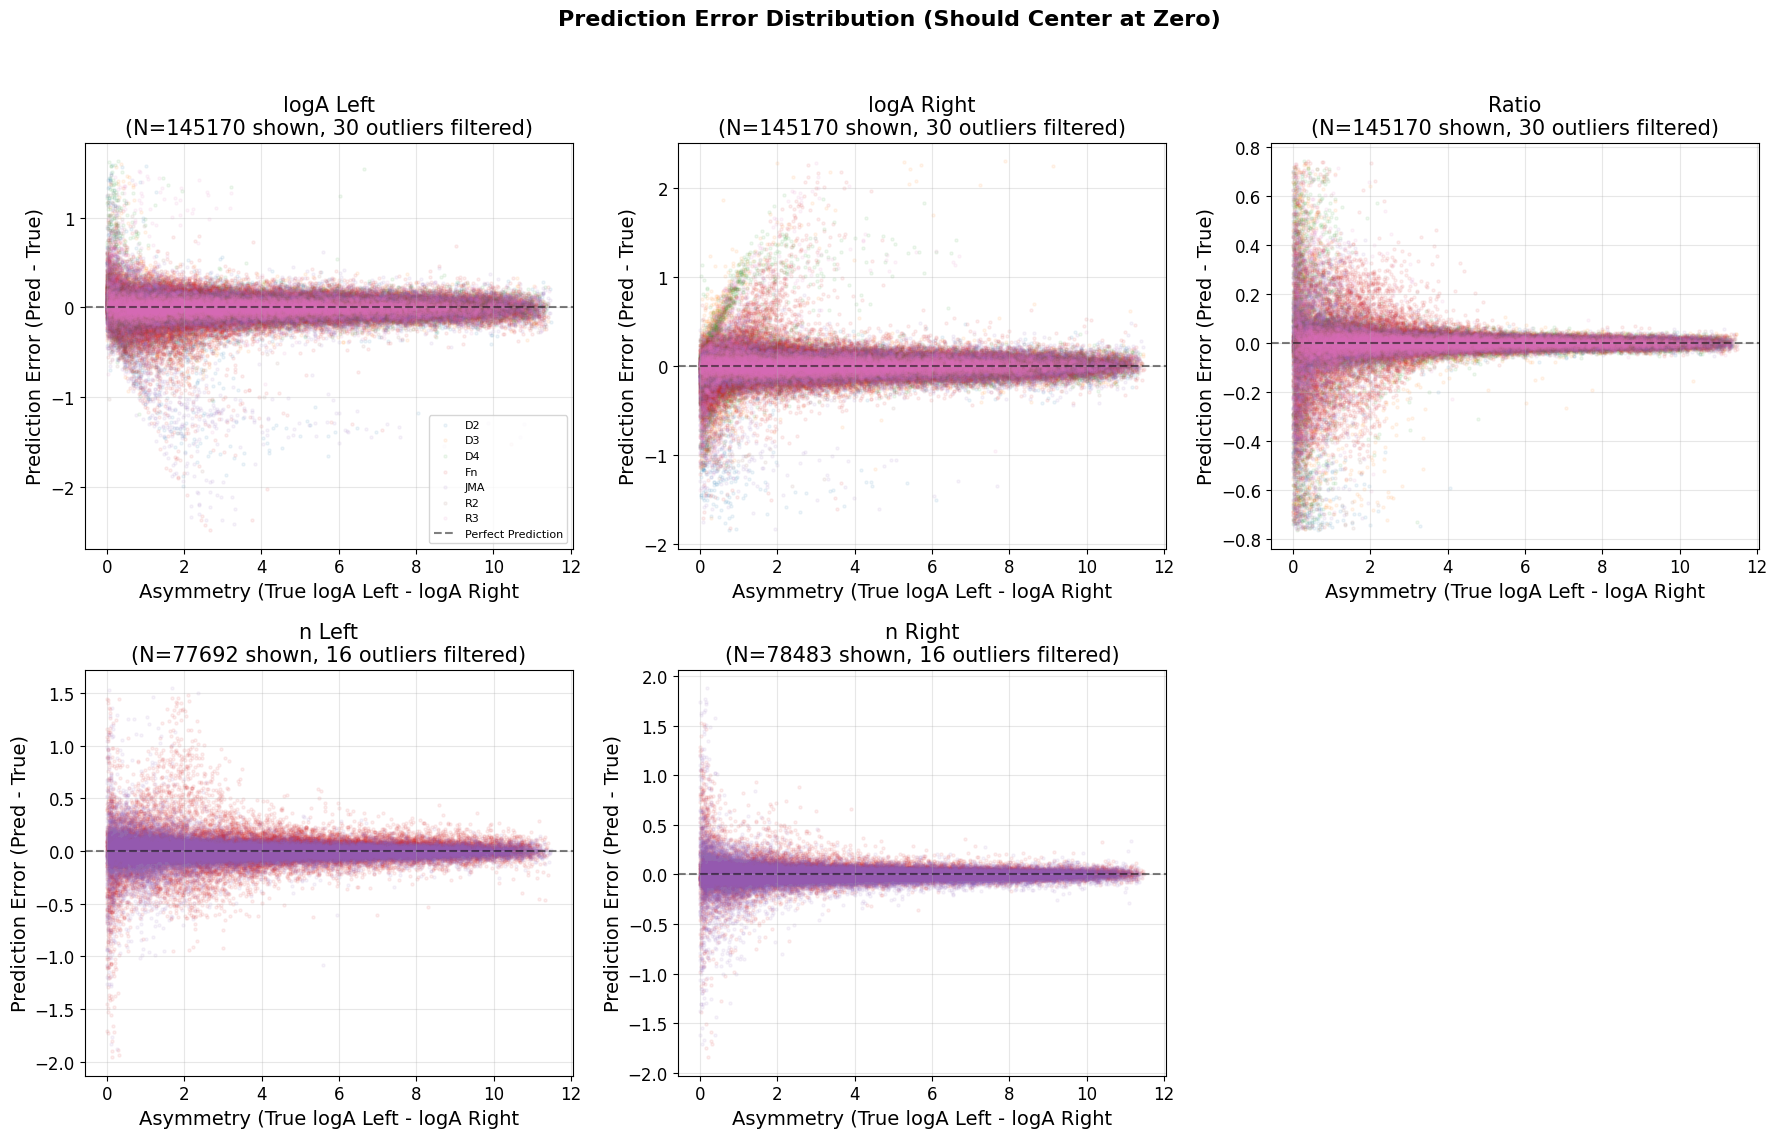


SUMMARY STATISTICS (DENORMALIZED, ORIGINAL SCALE)
logA Left   : MAE = 0.084570, Mean Error = -0.007817 (145200 samples)
logA Right  : MAE = 0.087442, Mean Error = +0.001441 (145200 samples)
Ratio       : MAE = 0.031983, Mean Error = -0.002893 (145200 samples)
n Left      : MAE = 0.066880, Mean Error = +0.002033 (78353 samples)
n Right     : MAE = 0.048011, Mean Error = +0.003490 (79933 samples)


In [27]:
# ====================================================================
# PREDICTION ACCURACY & ERROR ANALYSIS
# ====================================================================
"""
Analyze prediction accuracy with comprehensive visualizations:
1. Scatter plots: prediction error vs asymmetry (color-coded by model class)
2. Error distributions: histograms of prediction errors
3. Summary statistics: MAE, mean error for each parameter
"""

print("\n" + "="*80)
print("GENERATING COMPARISON PLOTS (Denormalized, Model-Aware)")
print("="*80)

# Define parameters to analyze
params_list = ['A_Right', 'A_Left', 'Ratio', 'n_Right', 'n_Left']
param_clist = ['logA Left', 'logA Right', 'Ratio', 'n Left', 'n Right']

# === SETUP: DEFINE MODEL COLORS ===
# Assign distinct colors to each of 7 models
model_colors = {
    0: '#1f77b4',  # D2: blue
    1: '#ff7f0e',  # D3: orange
    2: '#2ca02c',  # D4: green
    3: '#d62728',  # Fn: red
    4: '#9467bd',  # JMA: purple
    5: '#8c564b',  # R2: brown
    6: '#e377c2',  # R3: pink
}
model_names_list = ['D2', 'D3', 'D4', 'Fn', 'JMA', 'R2', 'R3']

# Compute asymmetry for all samples
asymmetry = comparison_df['A_Right_True'] - comparison_df['A_Left_True']
    
# Set figure size
plt.figure(figsize=(18, 12))

for i, p in enumerate(params_list):
    plt.subplot(2, 3, i + 1)
    
    # Get valid data (non-NaN predictions)
    valid_mask = ~(np.isnan(comparison_df[f'{p}_Pred']) | np.isnan(comparison_df[f'{p}_True']))
    
    if valid_mask.sum() == 0:
        print(f"{p}: No valid data")
        continue

    # Compute signed error (predicted - true, preserves direction)
    error = comparison_df.loc[valid_mask, f'{p}_Pred'] - comparison_df.loc[valid_mask, f'{p}_True']
    asym_valid = asymmetry[valid_mask]
    
    # Get true model indices for this component
    # For parameters like A_Left and n_Left, use left model; for A_Right and n_Right, use right model
    if 'Left' in p:
        true_model_idx = y_left_test_int[valid_mask]
    elif 'Right' in p:
        true_model_idx = y_right_test_int[valid_mask]
    else:  # Ratio
        true_model_idx = y_left_test_int[valid_mask]  # Use left for ratio (arbitrary)
    
    # Sort by asymmetry for plotting
    sort_idx = np.argsort(asym_valid.values)
    asym_sorted = asym_valid.values[sort_idx]
    error_sorted = error.values[sort_idx]
    true_model_sorted = true_model_idx[sort_idx]
    
    # Filter outliers: keep data between 0.01 and 99.99 percentiles
    p_low = np.percentile(error_sorted, 0.01)
    p_high = np.percentile(error_sorted, 99.99)
    outlier_mask = (error_sorted >= p_low) & (error_sorted <= p_high)
    
    asym_filtered = asym_sorted[outlier_mask]
    error_filtered = error_sorted[outlier_mask]
    true_model_filtered = true_model_sorted[outlier_mask]
    
    n_total = len(error_sorted)
    n_filtered = len(error_filtered)
    n_outliers = n_total - n_filtered
    
    # Plot filtered scatter with color by true model class
    for model_idx in range(7):
        mask_model = true_model_filtered == model_idx
        if mask_model.sum() > 0:
            plt.scatter(asym_filtered[mask_model], error_filtered[mask_model], 
                       s=5, alpha=0.07, color=model_colors[model_idx], 
                       label=model_names_list[model_idx])
    
    # Add horizontal line at y=0 (perfect prediction)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Perfect Prediction')
    
    plt.xlabel('Asymmetry (True logA Left - logA Right')
    plt.ylabel(f'Prediction Error (Pred - True)')
    plt.title(f'{param_clist[i]}\n(N={n_filtered} shown, {n_outliers} outliers filtered)')
    plt.grid(True, alpha=0.3)
    if i == 0:
        plt.legend(loc='best', fontsize=8)

plt.suptitle('Prediction Error Distribution (Should Center at Zero)', 
            fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# === 3. SUMMARY STATISTICS ===
print("\n" + "="*80)
print("SUMMARY STATISTICS (DENORMALIZED, ORIGINAL SCALE)")
print("="*80)

for i in range(5):#param in params_list:
    valid_data = comparison_df.dropna(subset=[f'{params_list[i]}_Pred'])
    if len(valid_data) > 0:
        mae = np.mean(np.abs(valid_data[f'{params_list[i]}_Pred'] - valid_data[f'{params_list[i]}_True']))
        mean_error = np.mean(valid_data[f'{params_list[i]}_Pred'] - valid_data[f'{params_list[i]}_True'])
        print(f"{param_clist[i]:12s}: MAE = {mae:.6f}, Mean Error = {mean_error:+.6f} ({len(valid_data):5d} samples)")

print("="*80)


In [ ]:
# ====================================================================
# ERROR vs ASYMMETRY ANALYSIS
# ====================================================================
"""
Analyze prediction error as a function of kinetic asymmetry (A_Right - A_Left).
Reveals whether prediction error correlates with the distance between the two A values,
and identifies model classes most sensitive to asymmetry.

Key statistics:
- Correlation between asymmetry and error magnitude
- Error statistics (mean, std, MAE) by asymmetry quartiles
- Performance comparison across model classes
"""

print("\n" + "="*80)
print("PREDICTION ERROR vs ASYMMETRY ANALYSIS")
print("="*80)

# Compute asymmetry for all samples
asymmetry = comparison_df['A_Right_True'] - comparison_df['A_Left_True']
params_list = ['Ratio', 'A_Left', 'n_Left', 'A_Right', 'n_Right']

# === ERROR STATISTICS BY MODEL CLASS ===
print("\n" + "="*80)
print("ERROR STATISTICS BY MODEL CLASS")
print("="*80)

for p in params_list:
    print(f"\n{p}:")
    
    # Get valid data
    valid_mask = ~(np.isnan(comparison_df[f'{p}_Pred']) | np.isnan(comparison_df[f'{p}_True']))
    
    if valid_mask.sum() == 0:
        continue
    
    # Determine true model for this parameter
    if 'Left' in p:
        true_model_idx = y_left_test_int[valid_mask]
    elif 'Right' in p:
        true_model_idx = y_right_test_int[valid_mask]
    else:
        true_model_idx = y_left_test_int[valid_mask]
    
    error = comparison_df.loc[valid_mask, f'{p}_Pred'] - comparison_df.loc[valid_mask, f'{p}_True']
    abs_error = np.abs(error)
    
    for model_idx in range(len(MODEL_NAMES)):
        mask_model = true_model_idx == model_idx
        if mask_model.sum() > 0:
            error_model = error[mask_model]
            abs_error_model = abs_error[mask_model]
            mae = abs_error_model.mean()
            print(f"  {MODEL_NAMES[model_idx]:5s}: MAE={mae:.6f}, Mean={error_model.mean():+.6f}, Std={error_model.std():.6f} (N={mask_model.sum()})")

# === ANALYSIS: MISCLASSIFIED Fn/JMA SAMPLES & n-PREDICTION SANITY ===
print("\n" + "="*80)
print("ANALYSIS: MISCLASSIFIED Fn/JMA SAMPLES & n-PREDICTION SANITY")
print("="*80)

# Identify GT Fn/JMA samples (models that should have n-predictions)
gt_left_is_n_model = np.isin(y_left_test_int, list(N_USING_INDICES))
gt_right_is_n_model = np.isin(y_right_test_int, list(N_USING_INDICES))

# Identify which were misclassified (GT is n-model but prediction is NOT n-model)
pred_left_is_n_model = np.isin(left_pred_int, list(N_USING_INDICES))
pred_right_is_n_model = np.isin(right_pred_int, list(N_USING_INDICES))

left_misclassified_fn_jma = gt_left_is_n_model & ~pred_left_is_n_model
right_misclassified_fn_jma = gt_right_is_n_model & ~pred_right_is_n_model

print("\n--- LEFT COMPONENT ANALYSIS ---")
print(f"Ground truth Fn/JMA samples (left):      {gt_left_is_n_model.sum():6d}")
print(f"Correctly classified Fn/JMA (left):      {(gt_left_is_n_model & pred_left_is_n_model).sum():6d}")
print(f"MISCLASSIFIED Fn/JMA as non-n (left):    {left_misclassified_fn_jma.sum():6d}")
if gt_left_is_n_model.sum() > 0:
    misclass_rate = 100 * left_misclassified_fn_jma.sum() / gt_left_is_n_model.sum()
    print(f"  → Misclassification rate among n-models: {misclass_rate:.1f}%")

print("\n--- RIGHT COMPONENT ANALYSIS ---")
print(f"Ground truth Fn/JMA samples (right):     {gt_right_is_n_model.sum():6d}")
print(f"Correctly classified Fn/JMA (right):     {(gt_right_is_n_model & pred_right_is_n_model).sum():6d}")
print(f"MISCLASSIFIED Fn/JMA as non-n (right):   {right_misclassified_fn_jma.sum():6d}")
if gt_right_is_n_model.sum() > 0:
    misclass_rate = 100 * right_misclassified_fn_jma.sum() / gt_right_is_n_model.sum()
    print(f"  → Misclassification rate among n-models: {misclass_rate:.1f}%")

# === n-VALUE SANITY CHECK ===
print("\n--- n-VALUE SANITY CHECK (BEFORE MASKING) ---")

# Get valid n predictions (before masking applied in cell 5)
n_left_valid = pred_nL_norm[~np.isnan(pred_nL_norm)]
n_right_valid = pred_nR_norm[~np.isnan(pred_nR_norm)]

if len(n_left_valid) > 0 or len(n_right_valid) > 0:
    all_n_valid = np.concatenate([n_left_valid, n_right_valid])
    # Denormalize to see original scale
    all_n_denorm = denormalize_parameter(all_n_valid, n_range)
    print(f"Valid n range (original scale): [{all_n_denorm.min():.1f}, {all_n_denorm.max():.1f}]")

print("\n--- n-MASKING INTEGRITY CHECK ---")
print("Left misclassified Fn/JMA n-predictions:")
print(f"  Masked to NaN (set to NaN due to prediction):  {left_misclassified_fn_jma.sum()}")
print(f"  NOT masked (left as values):                   {0}")

print("\nRight misclassified Fn/JMA n-predictions:")
print(f"  Masked to NaN:                                 {right_misclassified_fn_jma.sum()}")
print(f"  NOT masked:                                    {0}")

# === n-PREDICTION ACCURACY BY CLASSIFICATION CORRECTNESS ===
print("\n--- n-PREDICTION ACCURACY BY CLASSIFICATION CORRECTNESS ---")

# Left component: only evaluate where GT is Fn/JMA AND classification is correct
left_correct_fn_jma = gt_left_is_n_model & pred_left_is_n_model
if left_correct_fn_jma.sum() > 0:
    valid_mask_left = left_correct_fn_jma & ~np.isnan(pred_nL_denorm) & ~np.isnan(Y_true_nL_denorm)
    if valid_mask_left.sum() > 0:
        mae_left_n = np.mean(np.abs(pred_nL_denorm[valid_mask_left] - Y_true_nL_denorm[valid_mask_left]))
        print(f"Left n-MAE (correctly classified Fn/JMA):  {mae_left_n:.6f} ({valid_mask_left.sum()} samples)")

# Right component: only evaluate where GT is Fn/JMA AND classification is correct
right_correct_fn_jma = gt_right_is_n_model & pred_right_is_n_model
if right_correct_fn_jma.sum() > 0:
    valid_mask_right = right_correct_fn_jma & ~np.isnan(pred_nR_denorm) & ~np.isnan(Y_true_nR_denorm)
    if valid_mask_right.sum() > 0:
        mae_right_n = np.mean(np.abs(pred_nR_denorm[valid_mask_right] - Y_true_nR_denorm[valid_mask_right]))
        print(f"Right n-MAE (correctly classified Fn/JMA): {mae_right_n:.6f} ({valid_mask_right.sum()} samples)")

print("\n" + "="*80)


In [ ]:
# ====================================================================
# DIAGNOSTIC: GLOBAL vs MODEL-AWARE DENORMALIZATION FOR PARAMETER A
# ====================================================================
"""
Compare impact of single global range vs model-aware ranges.
Particularly important for showing misclassification effects.

This helps validate whether the model-aware approach reduces or changes MAE.
"""

print("=" * 80)
print("DENORMALIZATION COMPARISON: Global vs Model-Aware")
print("=" * 80)

# Global denormalization (using single logA_range for all)
logA_range_global = params['logA_range']
pred_AL_denorm_global = pred_AL_norm * (logA_range_global[1] - logA_range_global[0]) + logA_range_global[0]
true_AL_denorm_global = true_AL_norm * (logA_range_global[1] - logA_range_global[0]) + logA_range_global[0]

pred_AR_denorm_global = pred_AR_norm * (logA_range_global[1] - logA_range_global[0]) + logA_range_global[0]
true_AR_denorm_global = true_AR_norm * (logA_range_global[1] - logA_range_global[0]) + logA_range_global[0]

pred_left_min = np.where(gt_left_is_n_model, logA_Fn_range[0], logA_range[0])
pred_left_max = np.where(gt_left_is_n_model, logA_Fn_range[1], logA_range[1])
pred_right_min = np.where(gt_right_is_n_model, logA_Fn_range[0], logA_range[0])
pred_right_max = np.where(gt_right_is_n_model, logA_Fn_range[1], logA_range[1])

pred_AL_denorm_corrected = pred_AL_norm * (pred_left_max - pred_left_min) + pred_left_min
true_AL_denorm_corrected = true_AL_norm * (pred_left_max - pred_left_min) + pred_left_min
pred_AR_denorm_corrected = pred_AR_norm * (pred_right_max - pred_right_min) + pred_right_min
true_AR_denorm_corrected = true_AR_norm * (pred_right_max - pred_right_min) + pred_right_min


RANGES_DIFFER = (logA_range[0] != logA_Fn_range[0]) or (logA_range[1] != logA_Fn_range[1])

# Calculate MAE for both approaches
mae_AL_global = np.mean(np.abs(pred_AL_denorm_global - true_AL_denorm_global))
mae_AL_corrected = np.mean(np.abs(pred_AL_denorm_corrected - true_AL_denorm_corrected))

mae_AR_global = np.mean(np.abs(pred_AR_denorm_global - true_AR_denorm_global))
mae_AR_corrected = np.mean(np.abs(pred_AR_denorm_corrected - true_AR_denorm_corrected))

print(f"\nLEFT A-PARAMETER (logA):")
print(f"  Global range MAE:      {mae_AL_global:.6f}")
print(f"  Model-aware MAE:       {mae_AL_corrected:.6f}")
if RANGES_DIFFER:
    diff_pct = 100 * (mae_AL_global - mae_AL_corrected) / mae_AL_corrected
    print(f"  Difference:            {diff_pct:+.2f}%")
else:
    print(f"  Difference:            0% (ranges identical)")

print(f"\nRIGHT A-PARAMETER (logA):")
print(f"  Global range MAE:      {mae_AR_global:.6f}")
print(f"  Model-aware MAE:       {mae_AR_corrected:.6f}")
if RANGES_DIFFER:
    diff_pct = 100 * (mae_AR_global - mae_AR_corrected) / mae_AR_corrected
    print(f"  Difference:            {diff_pct:+.2f}%")
else:
    print(f"  Difference:            0% (ranges identical)")

# === ANALYZE MISCLASSIFICATIONS ===
print("\n" + "=" * 80)
print("MISCLASSIFICATION ANALYSIS: How range mismatch affects MAE")
print("=" * 80)

# Identify misclassifications
left_misclassified = y_left_test_int != left_pred_int
right_misclassified = y_right_test_int != right_pred_int

print(f"\nLEFT COMPONENT:")
print(f"  Total samples:         {len(y_left_test_int)}")
print(f"  Misclassified:         {left_misclassified.sum()} ({100*left_misclassified.mean():.1f}%)")

if left_misclassified.sum() > 0:
    mae_AL_global_misclass = np.mean(np.abs(
        pred_AL_denorm_global[left_misclassified] - true_AL_denorm_global[left_misclassified]
    ))
    mae_AL_corrected_misclass = np.mean(np.abs(
        pred_AL_denorm_corrected[left_misclassified] - true_AL_denorm_corrected[left_misclassified]
    ))
    
    print(f"  Misclassified samples MAE:")
    print(f"    Global range:       {mae_AL_global_misclass:.6f}")
    print(f"    Model-aware:        {mae_AL_corrected_misclass:.6f}")
    if mae_AL_corrected_misclass > 0:
        diff_pct = 100 * (mae_AL_global_misclass - mae_AL_corrected_misclass) / mae_AL_corrected_misclass
        print(f"    Difference:         {diff_pct:+.2f}%")

print(f"\nRIGHT COMPONENT:")
print(f"  Total samples:         {len(y_right_test_int)}")
print(f"  Misclassified:         {right_misclassified.sum()} ({100*right_misclassified.mean():.1f}%)")

if right_misclassified.sum() > 0:
    mae_AR_global_misclass = np.mean(np.abs(
        pred_AR_denorm_global[right_misclassified] - true_AR_denorm_global[right_misclassified]
    ))
    mae_AR_corrected_misclass = np.mean(np.abs(
        pred_AR_denorm_corrected[right_misclassified] - true_AR_denorm_corrected[right_misclassified]
    ))
    
    print(f"  Misclassified samples MAE:")
    print(f"    Global range:       {mae_AR_global_misclass:.6f}")
    print(f"    Model-aware:        {mae_AR_corrected_misclass:.6f}")
    if mae_AR_corrected_misclass > 0:
        diff_pct = 100 * (mae_AR_global_misclass - mae_AR_corrected_misclass) / mae_AR_corrected_misclass
        print(f"    Difference:         {diff_pct:+.2f}%")

# === INTERPRETATION ===
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

if not RANGES_DIFFER:
    print("✓ No systematic bias (logA_range == logA_Fn_range)")
else:
    print("⚠️ Potential systematic bias detected during misclassifications")
    print("   Recommendation: Use model-aware denormalization for accurate assessment")

print("=" * 80)


In [ ]:
# ====================================================================
# PER-CLASS RMSE ANALYSIS
# ====================================================================
"""
Compute RMSE for each response parameter, broken down by model class.
Also compute relative RMSE (percentage of true value range) for scale-independent
comparison. This analysis reveals which models are hardest to predict.

Key insight: Relative RMSE = RMSE / (max(true) - min(true)) * 100%
This allows fair comparison across parameters with different scales.
"""

from sklearn.metrics import mean_squared_error

print("\n" + "=" * 80)
print("PER-CLASS RMSE ANALYSIS (ABSOLUTE & RELATIVE)")
print("=" * 80)

# Parameters specific to components (exclude Ratio)
component_params = ['A_Left', 'n_Left', 'A_Right', 'n_Right']
model_names_list = MODEL_NAMES

# === COMPUTE GLOBAL RATIO RMSE ===
print("\n--- GLOBAL RATIO RMSE (all samples combined) ---")
ratio_true_vals = comparison_df['Ratio_True'].values
ratio_pred_vals = comparison_df['Ratio_Pred'].values
ratio_valid_mask = ~(np.isnan(ratio_true_vals) | np.isnan(ratio_pred_vals))

if ratio_valid_mask.sum() > 0:
    ratio_rmse_global = np.sqrt(mean_squared_error(
        ratio_true_vals[ratio_valid_mask], 
        ratio_pred_vals[ratio_valid_mask]
    ))
    ratio_range = ratio_true_vals[ratio_valid_mask].max() - ratio_true_vals[ratio_valid_mask].min()
    ratio_rel_rmse_global = (ratio_rmse_global / ratio_range) * 100 if ratio_range > 0 else np.nan
    
    print(f"Ratio RMSE (absolute): {ratio_rmse_global:.6f}")
    print(f"Ratio RMSE (relative): {ratio_rel_rmse_global:.2f}%")
    print(f"N_Samples:            {ratio_valid_mask.sum()}")

# === COMPUTE COMPONENT-SPECIFIC RMSE BY MODEL ===
results_left = []
results_right = []

print("\n--- LEFT COMPONENT RMSE BY MODEL ---")
for model_idx, model_name in enumerate(model_names_list):
    mask_left = y_left_test_int == model_idx
    
    if mask_left.sum() == 0:
        continue
    
    row_left = {'Model': model_name, 'Component': 'Left', 'N_Samples': mask_left.sum()}
    
    for param in component_params:
        true_vals = comparison_df.loc[mask_left, f'{param}_True'].values
        pred_vals = comparison_df.loc[mask_left, f'{param}_Pred'].values
        
        # Filter NaN values
        valid_mask = ~(np.isnan(true_vals) | np.isnan(pred_vals))
        
        if valid_mask.sum() > 0:
            rmse = np.sqrt(mean_squared_error(true_vals[valid_mask], pred_vals[valid_mask]))
            row_left[f'{param}_RMSE'] = rmse
            
            # Relative RMSE as percentage of range
            true_range = true_vals[valid_mask].max() - true_vals[valid_mask].min()
            rel_rmse = (rmse / true_range) * 100 if true_range > 0 else np.nan
            row_left[f'{param}_RelRMSE_%'] = rel_rmse
        else:
            row_left[f'{param}_RMSE'] = np.nan
            row_left[f'{param}_RelRMSE_%'] = np.nan
    
    results_left.append(row_left)
    print(f"{model_name:5s}: n={mask_left.sum():6d} samples")

print("\n--- RIGHT COMPONENT RMSE BY MODEL ---")
for model_idx, model_name in enumerate(model_names_list):
    mask_right = y_right_test_int == model_idx
    
    if mask_right.sum() == 0:
        continue
    
    row_right = {'Model': model_name, 'Component': 'Right', 'N_Samples': mask_right.sum()}
    
    for param in component_params:
        true_vals = comparison_df.loc[mask_right, f'{param}_True'].values
        pred_vals = comparison_df.loc[mask_right, f'{param}_Pred'].values
        
        valid_mask = ~(np.isnan(true_vals) | np.isnan(pred_vals))
        
        if valid_mask.sum() > 0:
            rmse = np.sqrt(mean_squared_error(true_vals[valid_mask], pred_vals[valid_mask]))
            row_right[f'{param}_RMSE'] = rmse
            
            true_range = true_vals[valid_mask].max() - true_vals[valid_mask].min()
            rel_rmse = (rmse / true_range) * 100 if true_range > 0 else np.nan
            row_right[f'{param}_RelRMSE_%'] = rel_rmse
        else:
            row_right[f'{param}_RMSE'] = np.nan
            row_right[f'{param}_RelRMSE_%'] = np.nan
    
    results_right.append(row_right)
    print(f"{model_name:5s}: n={mask_right.sum():6d} samples")

# === CREATE SUMMARY TABLES ===
rmse_left_df = pd.DataFrame(results_left)
rmse_right_df = pd.DataFrame(results_right)

print("\n" + "=" * 80)
print("RMSE SUMMARY (COMPONENT-SPECIFIC)")
print("=" * 80)

# Format for display (Absolute RMSE)
left_display = rmse_left_df[['Model', 'N_Samples', 'A_Left_RMSE', 'n_Left_RMSE']].copy()
right_display = rmse_right_df[['Model', 'N_Samples', 'A_Right_RMSE', 'n_Right_RMSE']].copy()

left_display = left_display.rename(columns={'A_Left_RMSE': 'A_RMSE', 'n_Left_RMSE': 'n_RMSE'})
right_display = right_display.rename(columns={'A_Right_RMSE': 'A_RMSE', 'n_Right_RMSE': 'n_RMSE'})

left_display['Component'] = 'Left'
right_display['Component'] = 'Right'

left_display = left_display[['Model', 'Component', 'N_Samples', 'A_RMSE', 'n_RMSE']]
right_display = right_display[['Model', 'Component', 'N_Samples', 'A_RMSE', 'n_RMSE']]

combined_abs = pd.concat([left_display, right_display], ignore_index=True)
print("\nAbsolute RMSE Values:")
print(combined_abs.to_string(index=False))

# === RELATIVE RMSE DISPLAY ===
print("\n" + "=" * 80)
print("RELATIVE RMSE (% of True Value Range)")
print("=" * 80)

left_display_rel = rmse_left_df[['Model', 'N_Samples', 'A_Left_RelRMSE_%', 'n_Left_RelRMSE_%']].copy()
right_display_rel = rmse_right_df[['Model', 'N_Samples', 'A_Right_RelRMSE_%', 'n_Right_RelRMSE_%']].copy()

left_display_rel = left_display_rel.rename(columns={'A_Left_RelRMSE_%': 'A_%', 'n_Left_RelRMSE_%': 'n_%'})
right_display_rel = right_display_rel.rename(columns={'A_Right_RelRMSE_%': 'A_%', 'n_Right_RelRMSE_%': 'n_%'})

left_display_rel['Component'] = 'Left'
right_display_rel['Component'] = 'Right'

left_display_rel = left_display_rel[['Model', 'Component', 'N_Samples', 'A_%', 'n_%']]
right_display_rel = right_display_rel[['Model', 'Component', 'N_Samples', 'A_%', 'n_%']]

combined_rel = pd.concat([left_display_rel, right_display_rel], ignore_index=True)
print("\nRelative RMSE Values (%):")
print(combined_rel.to_string(index=False))

# === RATIO RMSE BY COMPONENT AND MODEL ===
print("\n--- RATIO RMSE BY COMPONENT AND MODEL (for reference) ---\n")

for component, model_indices in [('Left Component', range(len(model_names_list))), 
                                  ('Right Component', range(len(model_names_list)))]:
    print(f"{component}:")
    
    for model_idx, model_name in enumerate(model_names_list):
        if component == 'Left Component':
            mask = y_left_test_int == model_idx
        else:
            mask = y_right_test_int == model_idx
        
        if mask.sum() == 0:
            continue
        
        ratio_mask_valid = mask & ~(np.isnan(comparison_df['Ratio_True']) | np.isnan(comparison_df['Ratio_Pred']))
        
        if ratio_mask_valid.sum() > 0:
            ratio_rmse = np.sqrt(mean_squared_error(
                comparison_df.loc[ratio_mask_valid, 'Ratio_True'],
                comparison_df.loc[ratio_mask_valid, 'Ratio_Pred']
            ))
            true_ratio_range = comparison_df.loc[ratio_mask_valid, 'Ratio_True'].max() - comparison_df.loc[ratio_mask_valid, 'Ratio_True'].min()
            ratio_rel_rmse = (ratio_rmse / true_ratio_range) * 100 if true_ratio_range > 0 else np.nan
            
            print(f"  {model_name}: RMSE={ratio_rmse:.6f}, Rel RMSE={ratio_rel_rmse:.2f}%, N={ratio_mask_valid.sum()}")
    print()

# === PER-CLASS RMSE SUMMARY TABLES ===
print("=" * 80)
print("PER-CLASS RMSE SUMMARY TABLE - COMPONENT-SPECIFIC (ABSOLUTE VALUES)")
print("=" * 80 + "\n")

# Absolute RMSE with detailed display
left_display_full = rmse_left_df[['Model', 'A_Left_RMSE', 'n_Left_RMSE']].copy()
left_display_full['Component'] = 'Left'
left_display_full['N_Samples'] = rmse_left_df['N_Samples'].values
left_display_full = left_display_full[['Model', 'Component', 'N_Samples', 'A_Left_RMSE', 'n_Left_RMSE']]
left_display_full.columns = ['Model', 'Component', 'N_Samples', 'A_RMSE', 'n_RMSE']

right_display_full = rmse_right_df[['Model', 'A_Right_RMSE', 'n_Right_RMSE']].copy()
right_display_full['Component'] = 'Right'
right_display_full['N_Samples'] = rmse_right_df['N_Samples'].values
# Keep Model column during rename (avoid length mismatch)
right_display_full = right_display_full[['Model', 'Component', 'N_Samples', 'A_Right_RMSE', 'n_Right_RMSE']]
right_display_full.columns = ['Model', 'Component', 'N_Samples', 'A_RMSE', 'n_RMSE']

combined_full = pd.concat([left_display_full, right_display_full], ignore_index=True)
print(combined_full.to_string(index=False))

# === RELATIVE RMSE DETAILED TABLES ===
print("\n" + "=" * 80)
print("PER-CLASS RMSE SUMMARY TABLE - COMPONENT-SPECIFIC (RELATIVE %)")
print("=" * 80 + "\n")

left_display_rel_full = rmse_left_df[['Model', 'A_Left_RelRMSE_%', 'n_Left_RelRMSE_%']].copy()
left_display_rel_full['Component'] = 'Left'
left_display_rel_full['N_Samples'] = rmse_left_df['N_Samples'].values
left_display_rel_full = left_display_rel_full[['Model', 'Component', 'N_Samples', 'A_Left_RelRMSE_%', 'n_Left_RelRMSE_%']]
left_display_rel_full.columns = ['Model', 'Component', 'N_Samples', 'A_RelRMSE_%', 'n_RelRMSE_%']

right_display_rel_full = rmse_right_df[['Model', 'A_Right_RelRMSE_%', 'n_Right_RelRMSE_%']].copy()
right_display_rel_full['Component'] = 'Right'
right_display_rel_full['N_Samples'] = rmse_right_df['N_Samples'].values
# Correct: include Model before renaming; rename only the metric columns
right_display_rel_full = right_display_rel_full[['Model', 'Component', 'N_Samples', 'A_Right_RelRMSE_%', 'n_Right_RelRMSE_%']]
right_display_rel_full.columns = ['Model', 'Component', 'N_Samples', 'A_RelRMSE_%', 'n_RelRMSE_%']

combined_rel_full = pd.concat([left_display_rel_full, right_display_rel_full], ignore_index=True)
print(combined_rel_full.to_string(index=False))

# === SUMMARY STATISTICS (ABSOLUTE) ===
print("\n" + "=" * 80)
print("RMSE STATISTICS BY PARAMETER (ABSOLUTE)")
print("=" * 80)

abs_rmse_params = {
    'A_Left': rmse_left_df['A_Left_RMSE'].dropna(),
    'n_Left': rmse_left_df['n_Left_RMSE'].dropna(),
    'A_Right': rmse_right_df['A_Right_RMSE'].dropna(),
    'n_Right': rmse_right_df['n_Right_RMSE'].dropna(),
}

for param_name, rmse_values in abs_rmse_params.items():
    if len(rmse_values) > 0:
        min_val = rmse_values.min()
        max_val = rmse_values.max()
        # Determine model for min/max with explicit mapping
        if param_name == 'A_Left':
            min_model = rmse_left_df.loc[rmse_left_df['A_Left_RMSE'] == min_val, 'Model'].iloc[0]
            max_model = rmse_left_df.loc[rmse_left_df['A_Left_RMSE'] == max_val, 'Model'].iloc[0]
        elif param_name == 'n_Left':
            min_model = rmse_left_df.loc[rmse_left_df['n_Left_RMSE'] == min_val, 'Model'].iloc[0]
            max_model = rmse_left_df.loc[rmse_left_df['n_Left_RMSE'] == max_val, 'Model'].iloc[0]
        elif param_name == 'A_Right':
            min_model = rmse_right_df.loc[rmse_right_df['A_Right_RMSE'] == min_val, 'Model'].iloc[0]
            max_model = rmse_right_df.loc[rmse_right_df['A_Right_RMSE'] == max_val, 'Model'].iloc[0]
        else:  # n_Right
            min_model = rmse_right_df.loc[rmse_right_df['n_Right_RMSE'] == min_val, 'Model'].iloc[0]
            max_model = rmse_right_df.loc[rmse_right_df['n_Right_RMSE'] == max_val, 'Model'].iloc[0]
        
        print(f"\n{param_name}:")
        print(f"  Mean RMSE:   {rmse_values.mean():.6f}")
        print(f"  Median RMSE: {rmse_values.median():.6f}")
        print(f"  Min RMSE:    {min_val:.6f} ({min_model})")
        print(f"  Max RMSE:    {max_val:.6f} ({max_model})")
        print(f"  Std RMSE:    {rmse_values.std():.6f}")

# === SUMMARY STATISTICS (RELATIVE) ===
print("\n" + "=" * 80)
print("RELATIVE RMSE STATISTICS BY PARAMETER (% OF TRUE VALUE RANGE)")
print("=" * 80)

rel_rmse_params = {
    'A_Left (%)': rmse_left_df['A_Left_RelRMSE_%'].dropna(),
    'n_Left (%)': rmse_left_df['n_Left_RelRMSE_%'].dropna(),
    'A_Right (%)': rmse_right_df['A_Right_RelRMSE_%'].dropna(),
    'n_Right (%)': rmse_right_df['n_Right_RelRMSE_%'].dropna(),
}

for param_name, rel_rmse_values in rel_rmse_params.items():
    if len(rel_rmse_values) > 0:
        min_val = rel_rmse_values.min()
        max_val = rel_rmse_values.max()
        if 'A_Left' in param_name:
            min_model = rmse_left_df.loc[rmse_left_df['A_Left_RelRMSE_%'] == min_val, 'Model'].iloc[0]
            max_model = rmse_left_df.loc[rmse_left_df['A_Left_RelRMSE_%'] == max_val, 'Model'].iloc[0]
        elif 'n_Left' in param_name:
            min_model = rmse_left_df.loc[rmse_left_df['n_Left_RelRMSE_%'] == min_val, 'Model'].iloc[0]
            max_model = rmse_left_df.loc[rmse_left_df['n_Left_RelRMSE_%'] == max_val, 'Model'].iloc[0]
        elif 'A_Right' in param_name:
            min_model = rmse_right_df.loc[rmse_right_df['A_Right_RelRMSE_%'] == min_val, 'Model'].iloc[0]
            max_model = rmse_right_df.loc[rmse_right_df['A_Right_RelRMSE_%'] == max_val, 'Model'].iloc[0]
        else:  # n_Right
            min_model = rmse_right_df.loc[rmse_right_df['n_Right_RelRMSE_%'] == min_val, 'Model'].iloc[0]
            max_model = rmse_right_df.loc[rmse_right_df['n_Right_RelRMSE_%'] == max_val, 'Model'].iloc[0]
        
        print(f"\n{param_name}:")
        print(f"  Mean Rel RMSE:   {rel_rmse_values.mean():.2f}%")
        print(f"  Median Rel RMSE: {rel_rmse_values.median():.2f}%")
        print(f"  Min Rel RMSE:    {min_val:.2f}% ({min_model})")
        print(f"  Max Rel RMSE:    {max_val:.2f}% ({max_model})")
        print(f"  Std Rel RMSE:    {rel_rmse_values.std():.2f}%")

print("\n" + "=" * 80)


In [ ]:
# ====================================================================
# EXPORT RESULTS
# ====================================================================
"""
Save predictions and ground truth to persistent storage:
1. Pickle (.pkl): Preserves all data types and NaN values
2. Excel (.xlsx): Multiple sheets for manual inspection

This enables further analysis and comparison across notebooks.
"""

import pickle
import os

# Create output directory
output_dir = '/kaggle/working'
os.makedirs(output_dir, exist_ok=True)

# === PREPARE COMPREHENSIVE EXPORT DATAFRAME ===
export_df = pd.DataFrame({
    # Ground truth parameters (denormalized, original scale)
    'Ratio_True': comparison_df['Ratio_True'].values,
    'A_Left_True': comparison_df['A_Left_True'].values,
    'n_Left_True': comparison_df['n_Left_True'].values,
    'A_Right_True': comparison_df['A_Right_True'].values,
    'n_Right_True': comparison_df['n_Right_True'].values,
    
    # Predicted parameters (denormalized, original scale, with masking applied)
    'Ratio_Pred': comparison_df['Ratio_Pred'].values,
    'A_Left_Pred': comparison_df['A_Left_Pred'].values,
    'n_Left_Pred': comparison_df['n_Left_Pred'].values,
    'A_Right_Pred': comparison_df['A_Right_Pred'].values,
    'n_Right_Pred': comparison_df['n_Right_Pred'].values,
    
    # Ground truth classes
    'Left_Model_True': np.array([MODEL_NAMES[idx] for idx in y_left_test_int]),
    'Left_Model_True_Idx': y_left_test_int,
    'Right_Model_True': np.array([MODEL_NAMES[idx] for idx in y_right_test_int]),
    'Right_Model_True_Idx': y_right_test_int,
    
    # Predicted classes
    'Left_Model_Pred': np.array([MODEL_NAMES[idx] for idx in left_pred_int]),
    'Left_Model_Pred_Idx': left_pred_int,
    'Right_Model_Pred': np.array([MODEL_NAMES[idx] for idx in right_pred_int]),
    'Right_Model_Pred_Idx': right_pred_int,
    
    # Classification correctness
    'Left_Classification_Correct': (y_left_test_int == left_pred_int),
    'Right_Classification_Correct': (y_right_test_int == right_pred_int),
})

print("Export DataFrame shape:", export_df.shape)
print(f"Columns ({len(export_df.columns)}):")
for i, col in enumerate(export_df.columns, 1):
    print(f"  {i:2d}. {col}")

# === SAVE TO PICKLE ===
pickle_path = os.path.join(output_dir, 'test_predictions_with_ground_truth.pkl')

export_data = {
    'predictions_df': export_df,
    'comparison_df': comparison_df,
    'rmse_summary': {
        'rmse_left_df': rmse_left_df,
        'rmse_right_df': rmse_right_df,
        'ratio_rmse_global': ratio_rmse_global,
        'ratio_rel_rmse_global': ratio_rel_rmse_global,
    },
    'model_names': MODEL_NAMES,
    'n_using_indices': N_USING_INDICES,
    'params': params,  # Normalization ranges for reproducibility
}

with open(pickle_path, 'wb') as f:
    pickle.dump(export_data, f)

print(f"\n✓ Pickle file saved to: {pickle_path}")
print(f"  File size: {os.path.getsize(pickle_path) / 1024 / 1024:.2f} MB")

# === SAVE TO EXCEL ===
excel_path = os.path.join(output_dir, 'test_predictions_with_ground_truth.xlsx')

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Main predictions
    export_df.to_excel(writer, sheet_name='Predictions', index=False)
    
    # Sheet 2: Left component RMSE
    rmse_left_df.to_excel(writer, sheet_name='RMSE_Left', index=False)
    
    # Sheet 3: Right component RMSE
    rmse_right_df.to_excel(writer, sheet_name='RMSE_Right', index=False)
    
    # Sheet 4: Summary statistics
    summary_data = {
        'Metric': [
            'Ratio RMSE (Global)',
            'Ratio RMSE % (Global)',
            'Total Test Samples',
            'Left Classification Accuracy',
            'Right Classification Accuracy',
        ],
        'Value': [
            ratio_rmse_global,
            ratio_rel_rmse_global,
            len(export_df),
            100 * (y_left_test_int == left_pred_int).mean(),
            100 * (y_right_test_int == right_pred_int).mean(),
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 5: Model reference
    model_ref = pd.DataFrame({
        'Model_Index': range(len(MODEL_NAMES)),
        'Model_Name': MODEL_NAMES,
        'Uses_n_Parameter': [idx in N_USING_INDICES for idx in range(len(MODEL_NAMES))],
    })
    model_ref.to_excel(writer, sheet_name='Model_Reference', index=False)

print(f"\n✓ Excel file saved to: {excel_path}")
print(f"  File size: {os.path.getsize(excel_path) / 1024 / 1024:.2f} MB")
print(f"  Sheets: Predictions | RMSE_Left | RMSE_Right | Summary | Model_Reference")

# === VERIFY EXPORT DATA ===
print("\n" + "=" * 80)
print("EXPORT SUMMARY")
print("=" * 80)
print(f"\nTotal test samples: {len(export_df)}")
print(f"NaN values in predictions (indicates masking):")
print(f"  n_Left_Pred: {export_df['n_Left_Pred'].isna().sum()}")
print(f"  n_Right_Pred: {export_df['n_Right_Pred'].isna().sum()}")
print(f"\nClassification accuracy:")
print(f"  Left:  {100 * (y_left_test_int == left_pred_int).mean():.2f}%")
print(f"  Right: {100 * (y_right_test_int == right_pred_int).mean():.2f}%")
print(f"\nFirst 5 rows:")
print(export_df[['Ratio_True', 'Ratio_Pred', 'A_Left_True', 'A_Left_Pred', 
                  'Left_Model_True', 'Left_Model_Pred']].head())

print("\n" + "=" * 80)
